# Overview

## Create the simulations

In [ ]:
import numpy as np
from lucifex.fem import cross_section_grid, mirror_grid
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz, Simulation
from lucifex.plt import (
    plot_line, save_figure, plot_colormap,
    get_ipynb_file_name, set_ipynb_variable, plot_streamlines,
    plot_colormap_multifigure, create_multifigure,
)
from lucifex.solver import OptionsPETSc
from lucifex.utils.fenicsx_utils import extract_component_functions
from crocodil.dns.system_d import dns_system_d, SYSTEM_D_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'./figures/{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 160)
NY = set_ipynb_variable('NY', 60)
ANIM = set_ipynb_variable('ANIM', False)

Ra = 600.0
PARAMS_PHYSICAL = SYSTEM_D_REFERENCE.replace(
    Ra=Ra, Pe=Ra, Da=2.0, 
    l=0.05, 
    inflow=('gaussian', 3.0), 
    p_dOmega='left', 
    mirror=-1,
)

theta_buoy_opts = (True, False)
simulations: dict[bool, Simulation] = {}

for theta_buoy in theta_buoy_opts:
    simulations[theta_buoy] = dns_system_d(
        store_delta=STORE, 
        write_delta=WRITE, 
        dir_root=DIR_ROOT, 
        dir_uid=True,
    )(
        Nx=NX,
        Ny=NY,
        cell='quadrilateral',
        scaling='advective',
        **PARAMS_PHYSICAL,
        theta_buoy=theta_buoy,
        dt_max=0.025,
        dt_Cu=None,
        dt_Cd=None,
        dt_Cr=None,
        c_stabilization=None,
        theta_stabilization=None,
        c_limits=True,
        theta_limits=True, 
        flow_petsc=OptionsPETSc(
            ksp_type='preonly', 
            pc_type='lu', 
            pc_factor_mat_solver_type='mumps',
            blocked=False,
            
        ),
        diagnostic=True,
    )

## Run the simulations

In [ ]:
n_stop = set_ipynb_variable('N_STOP', 100)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

for theta_buoy, sim in simulations.items():
    sim = simulations[theta_buoy]
    run(sim, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
    if WRITE: 
        xdmf_to_npz(sim, delete_xdmf=False)
    else:
        write(sim.parameters, sim.parameter_file, sim.dir_path, mode='w')

theta_title = lambda buoy: f"$\\theta_0^+={'0' if buoy else '1'}$"

mirror = PARAMS_PHYSICAL['mirror']
if mirror:
    mirrored = lambda u, rescale=1: mirror_grid(u, 'x', rescale)
else:
    mirrored = lambda u, *_: u

  0%|          | 0/100 [00:00<?, ?it/s]

INFO:root:running build_ext
INFO:root:building 'libffcx_forms_4e7f1440085fbb04831dc8454a81c2820fddbbd3' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_forms_4e7f1440085fbb04831dc8454a81c2820fddbbd3.c -o ./libffcx_forms_4e7f1440085fbb04831dc8454a81c2820fddbbd3.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_forms_4e7f1440085fbb04831dc8454a81c2820fddbbd3.o -o ./libffcx_forms_4e7f1440085fbb04831dc8454a81c2820fddbbd3.cpython-310-darwin.

  0%|          | 0/100 [00:00<?, ?it/s]

## Physical diagnostics

### Vertical velocity component

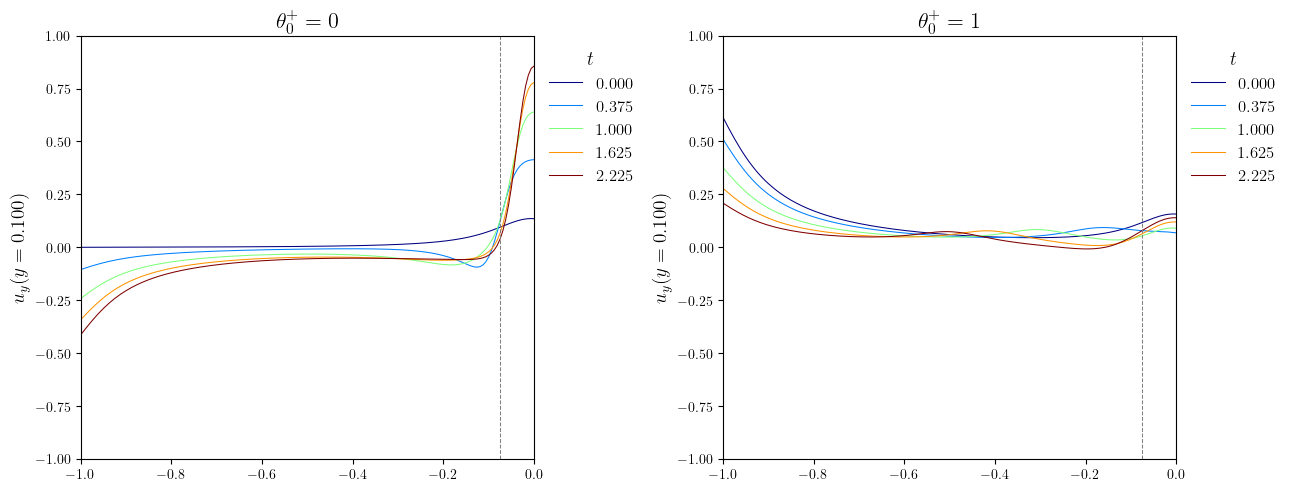

In [ ]:
time_indices = (*[int(i * n_stop) for i in (0, 0.25, 0.5, 0.75)], -1)
y_target = 0.1

vline_kws = dict(
    linestyles='dashed', linewidths=0.75, colors='gray',
)
mfig, axs, _ = create_multifigure(n_cols=2)

for n, (theta_buoy, sim) in enumerate(simulations.items()):
    u, uInMax, Lx, Ll, xIn = sim['u', 'uInMax', 'Lx', 'Ll', 'xIn']
    uy_lines = []
    t_labels = []
    for i in time_indices:
        uxi, uyi = extract_component_functions(('P', 1), u.get_series_item(i))
        uyi_grid, y_cs  = cross_section_grid(uyi, 'y', y_target)
        uy_lines.append(uyi_grid)
        t_labels.append(f'{u.time_series[i]:.3f}')
    plot_line(
        mfig, axs[n],
        uy_lines,
        cyc='jet',
        legend_labels=t_labels,
        legend_title='$t$',
        y_label=f'$u_y(y={y_cs:.3f})$',
        title=theta_title(theta_buoy),
    )
    y_lims = (-uInMax, uInMax)
    x_lims = Lx
    axs[n].vlines(xIn, *y_lims, **vline_kws)
    axs[n].set_xlim(*x_lims)
    axs[n].set_ylim(*y_lims)

### Solutal and thermal flux

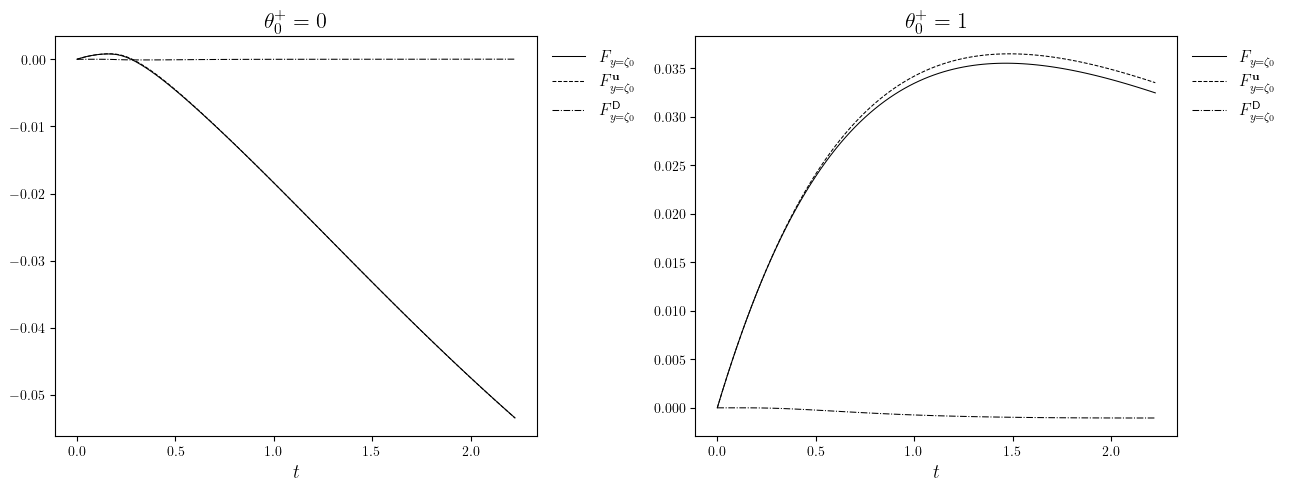

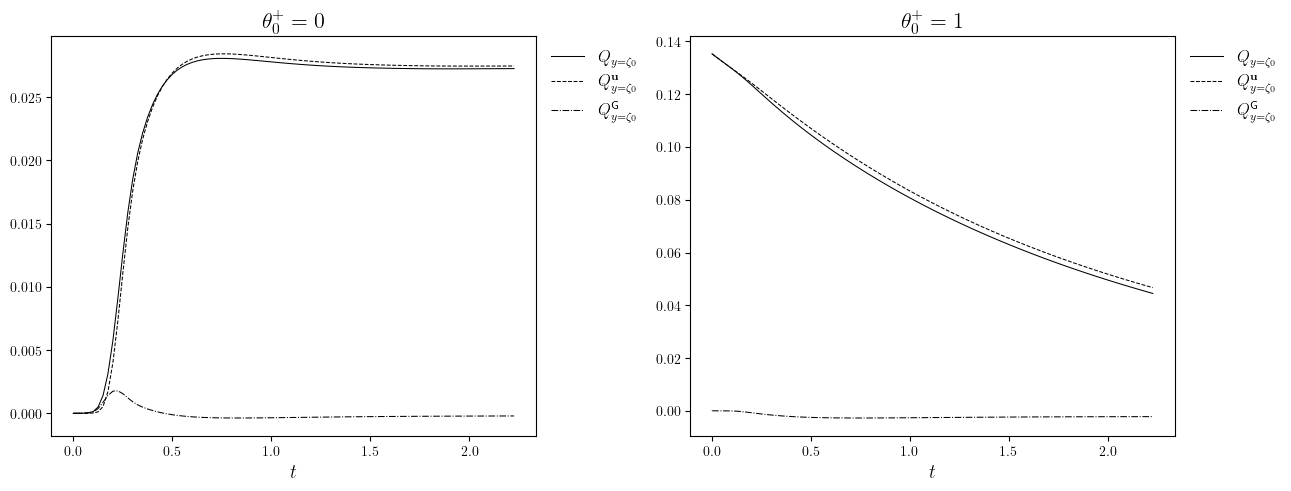

In [ ]:
mfig_f, axs_f, _ = create_multifigure(n_cols=2)
mfig_q, axs_q, _ = create_multifigure(n_cols=2)

for i, (theta_buoy, sim) in enumerate(simulations.items()):
    f, q = sim['f', 'q']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    qZeta0, qZetaPlus, qZetaMinus = q.split()
    plot_line(
        mfig_f, axs_f[i],
        [
            (fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]), 
            (fZeta0.time_series, fZeta0.value_series)
        ],
        cyc='black',
        x_label='$t$',
        title=theta_title(theta_buoy),
        legend_labels=[
            '$F_{y=\zeta_0}$', 
            '$F_{y=\zeta_0}^{\mathbf{u}}$', 
            '$F_{y=\zeta_0}^{\mathsf{D}}$',
        ],
    )
    plot_line(
         mfig_q, axs_q[i],
        [
            (qZeta0.time_series, [np.sum(i) for i in qZeta0.value_series]), 
            (qZeta0.time_series, qZeta0.value_series),
        ],
        cyc='black',
        x_label='$t$',
        title=theta_title(theta_buoy),
        legend_labels=[
            '$Q_{y=\zeta_0}$', 
            '$Q_{y=\zeta_0}^{\mathbf{u}}$', 
            '$Q_{y=\zeta_0}^{\mathsf{G}}$',
        ],
    )

## Visualization

### Concentration, temperature and saturation

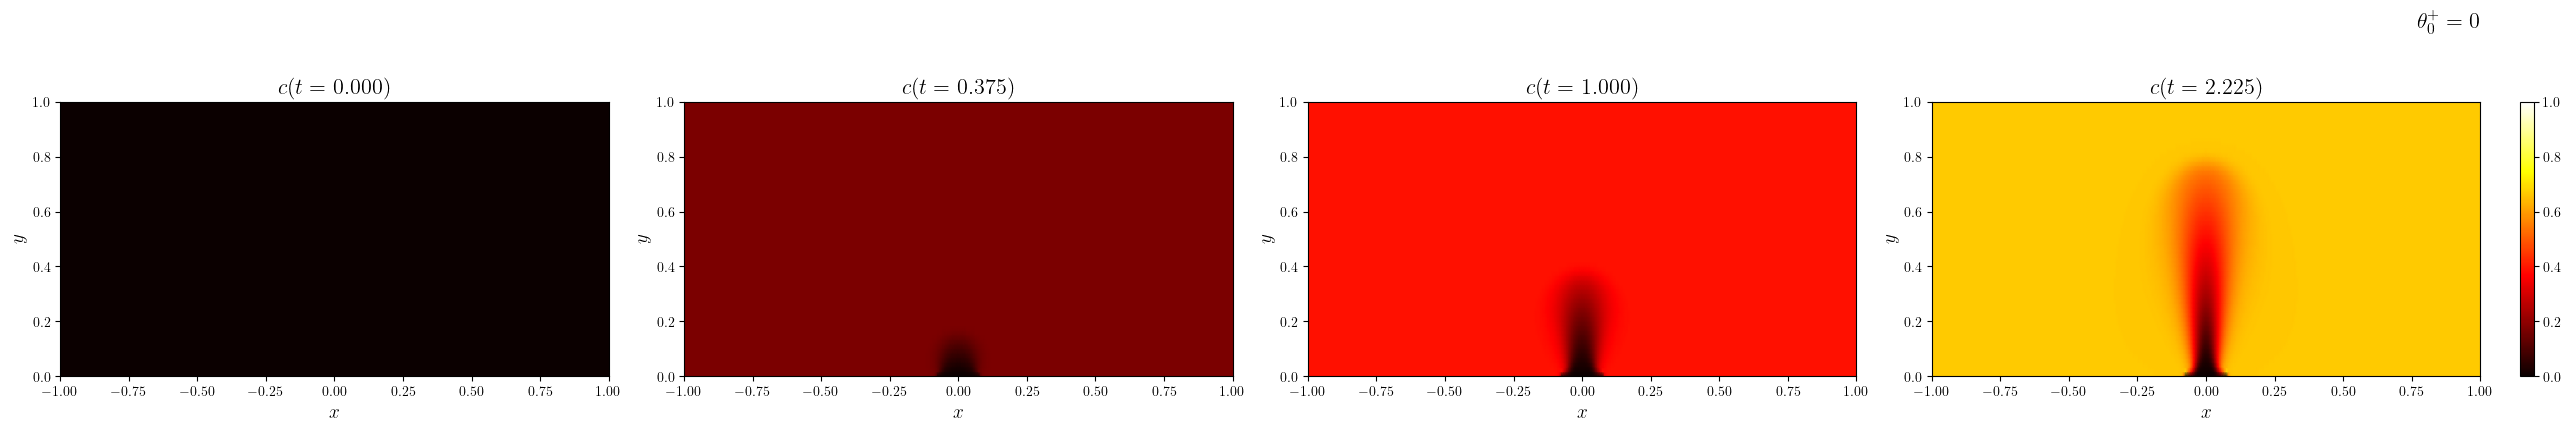

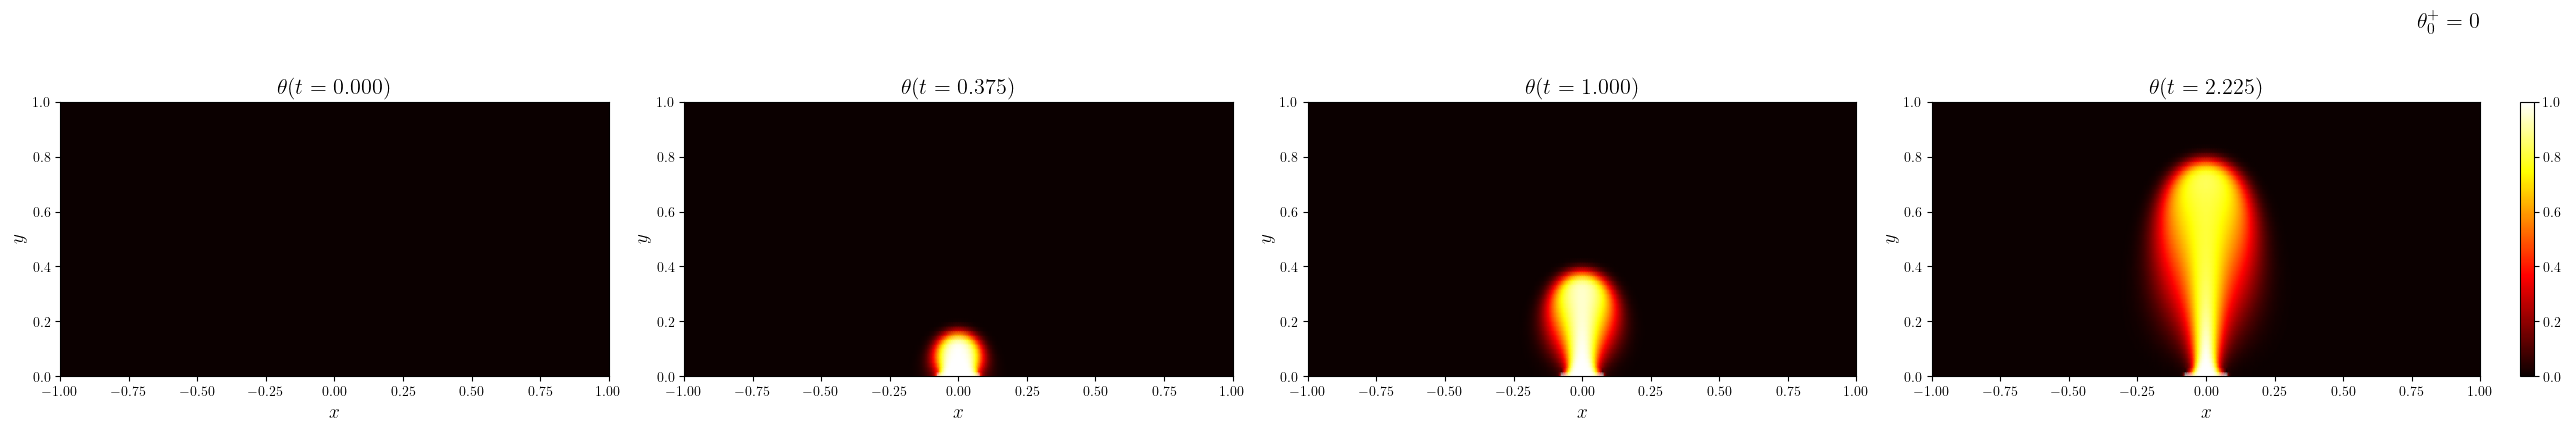

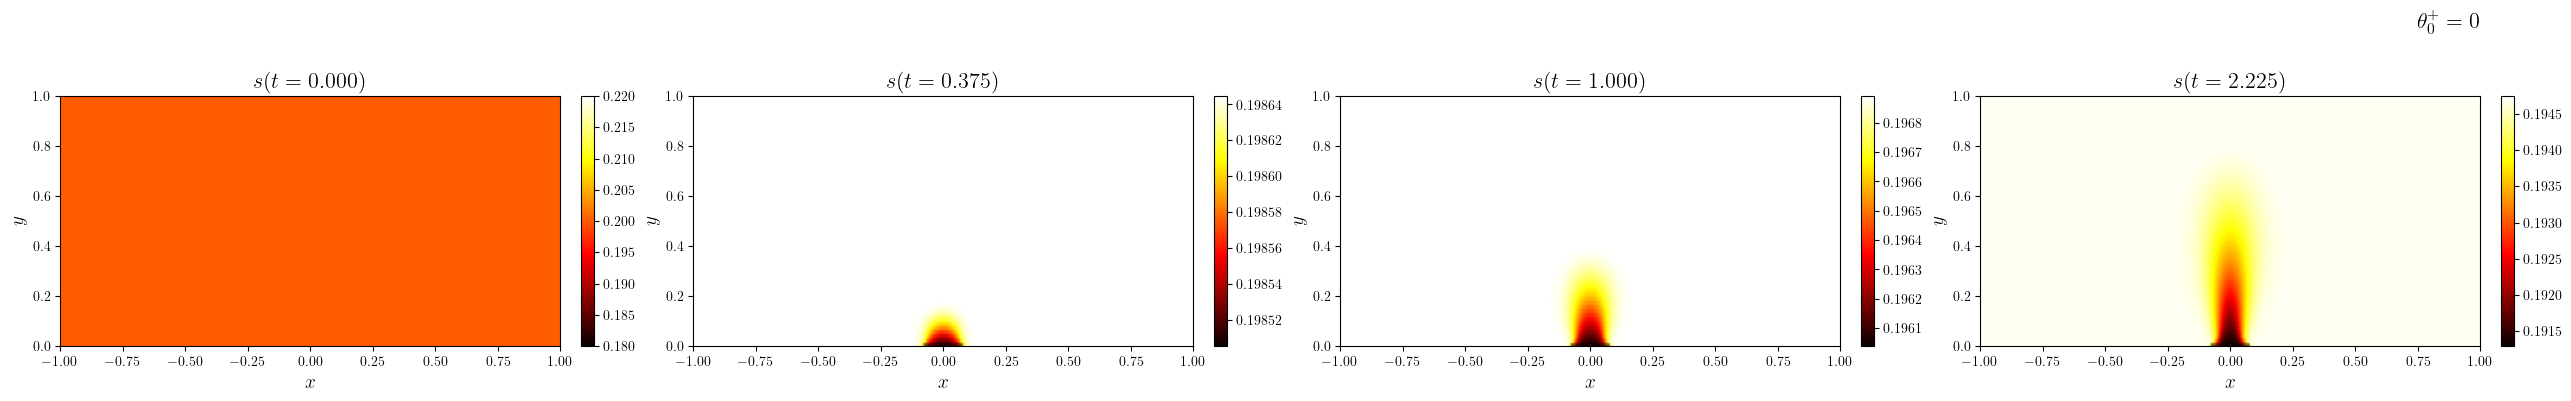

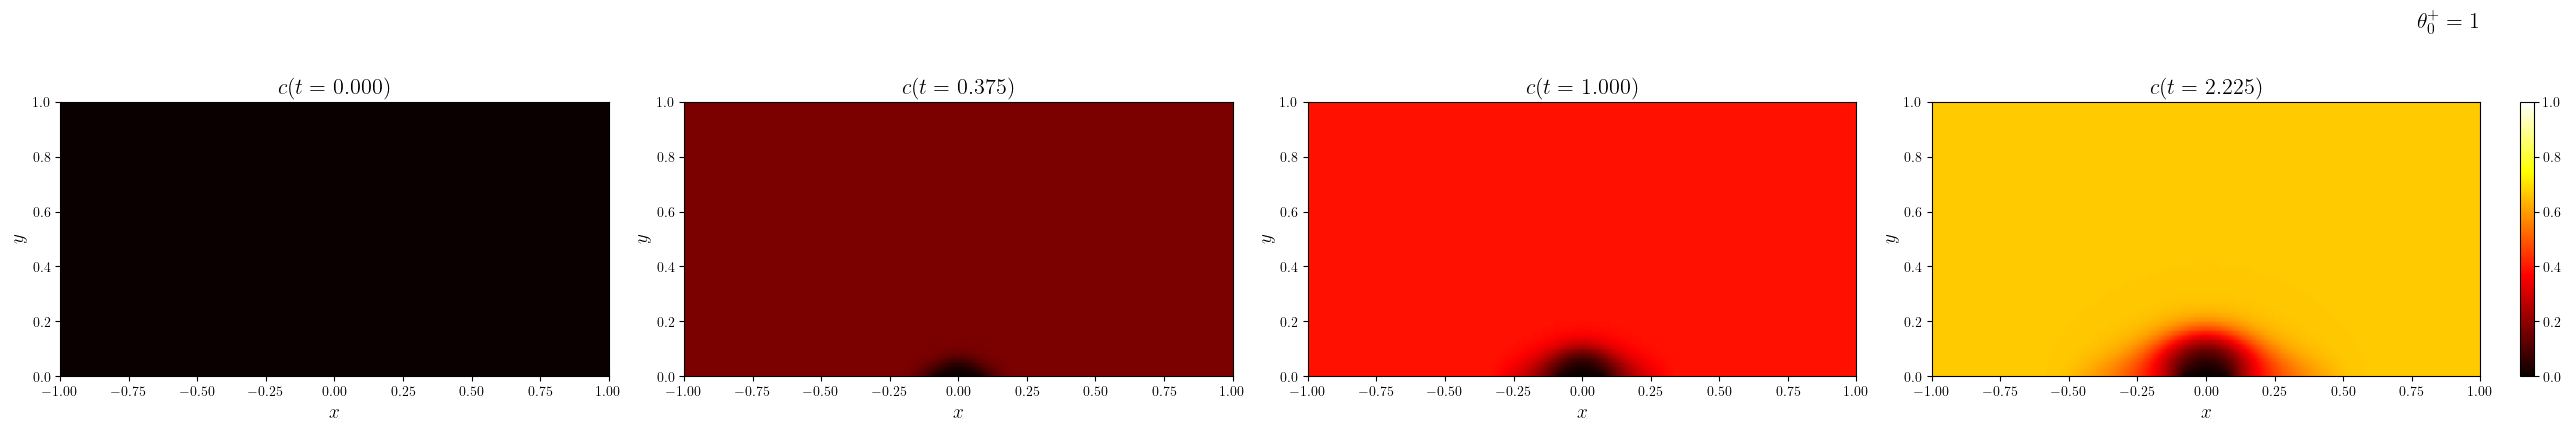

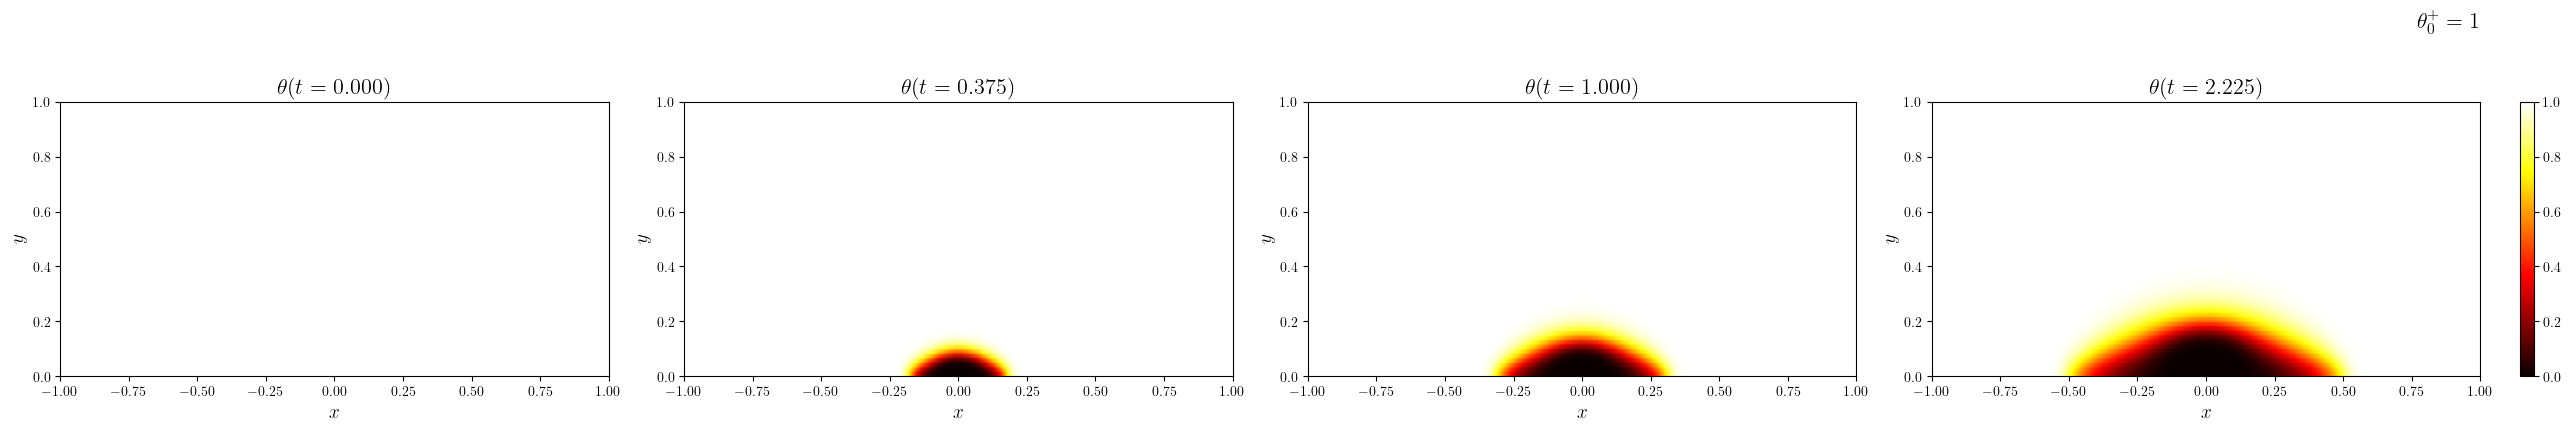

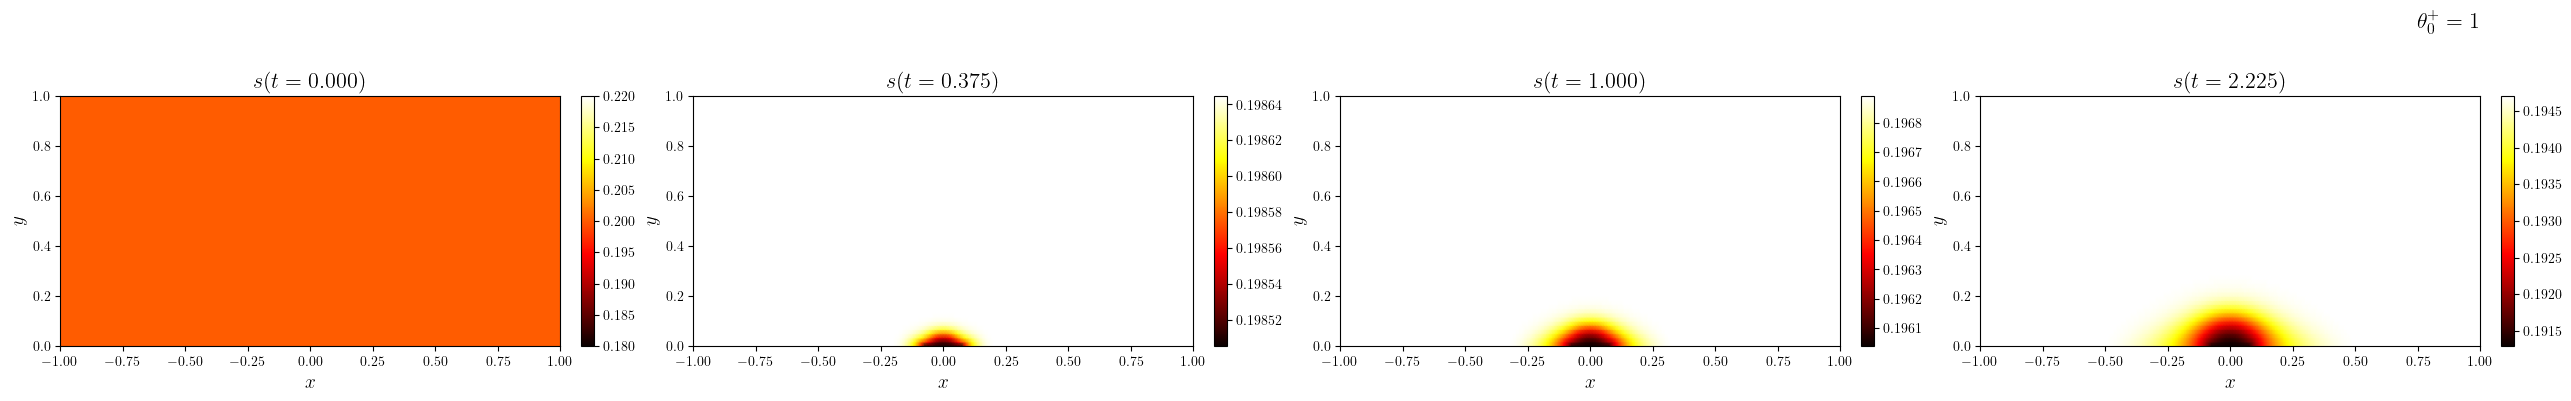

In [ ]:
time_indices = (*[int(i * n_stop) for i in (0, 0.25, 0.5)], -1)

for theta_buoy, sim in simulations.items():
    s, c, theta = sim['s', 'c', 'theta']
    sim = simulations[theta_buoy]
    mfig_c, *_ = plot_colormap_multifigure(
        n_cols=len(time_indices), 
        cbars=(0, 1),
        suptitle=theta_title(theta_buoy),
    )(
        [mirrored(c.series[i]) for i in time_indices],
        cmap='hot',
        title=[f'$c(t={c.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'c(t)_theta_buoy={theta_buoy}', sim.dir_path, prefix=False)(mfig_c)
    mfig_theta, *_ = plot_colormap_multifigure(
        n_cols=len(time_indices), 
        cbars=(0, 1),
        suptitle=theta_title(theta_buoy),
    )(
        [mirrored(theta.series[i]) for i in time_indices],
        cmap='hot',
        title=[f'$\\theta(t={theta.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'theta(t)_theta_buoy={theta_buoy}', sim.dir_path, prefix=False)(mfig_theta)
    mfig_s, *_ = plot_colormap_multifigure(
        n_cols=len(time_indices), 
        cbars=True,
        suptitle=theta_title(theta_buoy),
    )(
        [mirrored(s.series[i]) for i in time_indices],
        cmap='hot',
        title=[f'$s(t={s.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f's(t)_theta_buoy={theta_buoy}', sim.dir_path, prefix=False)(mfig_s)

### Pressure, streamlines and velocity components

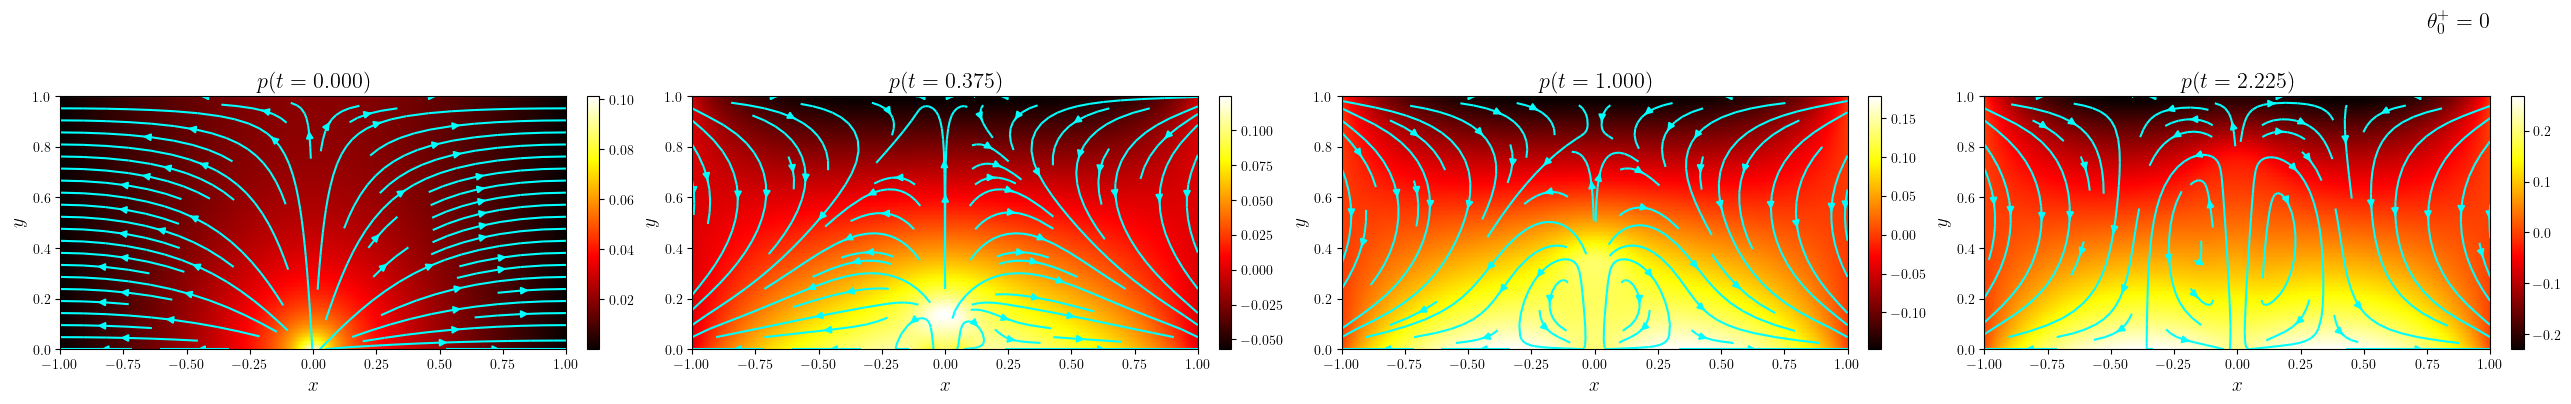

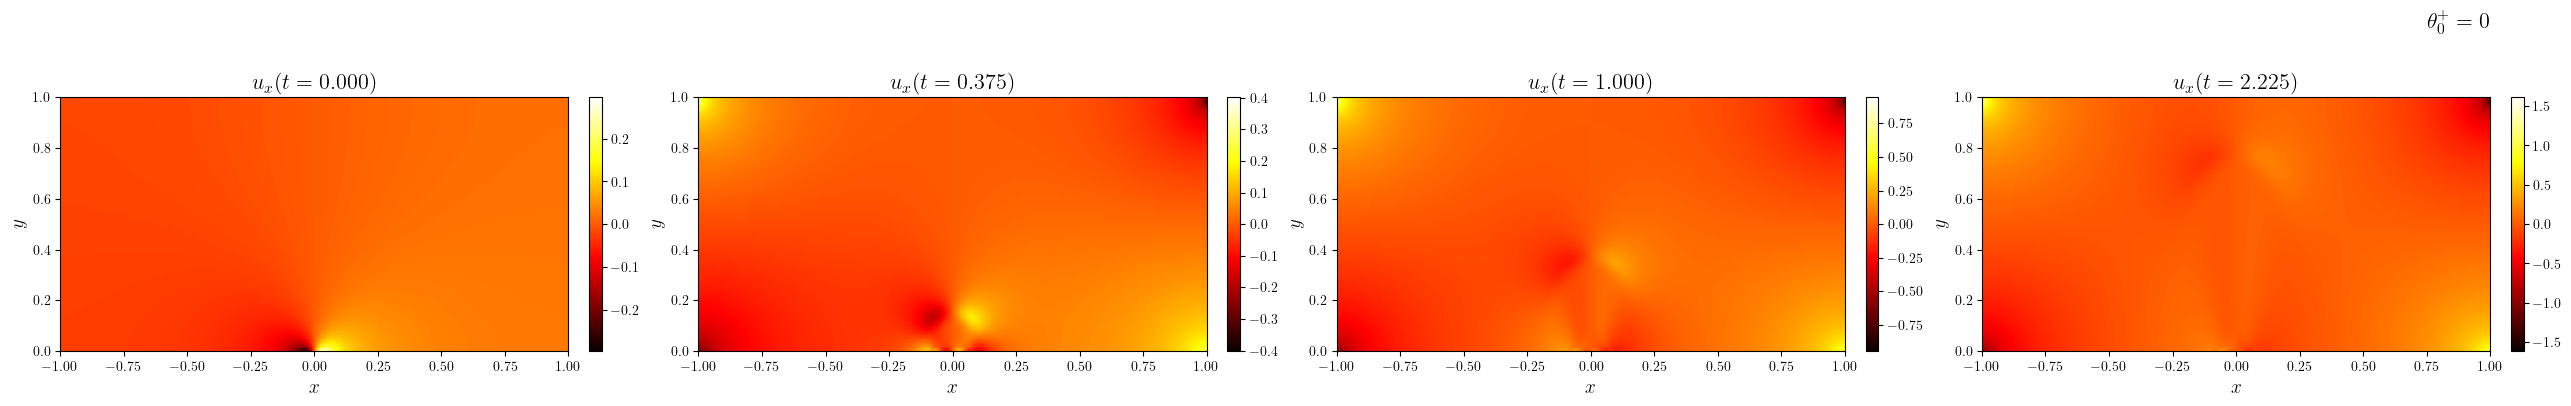

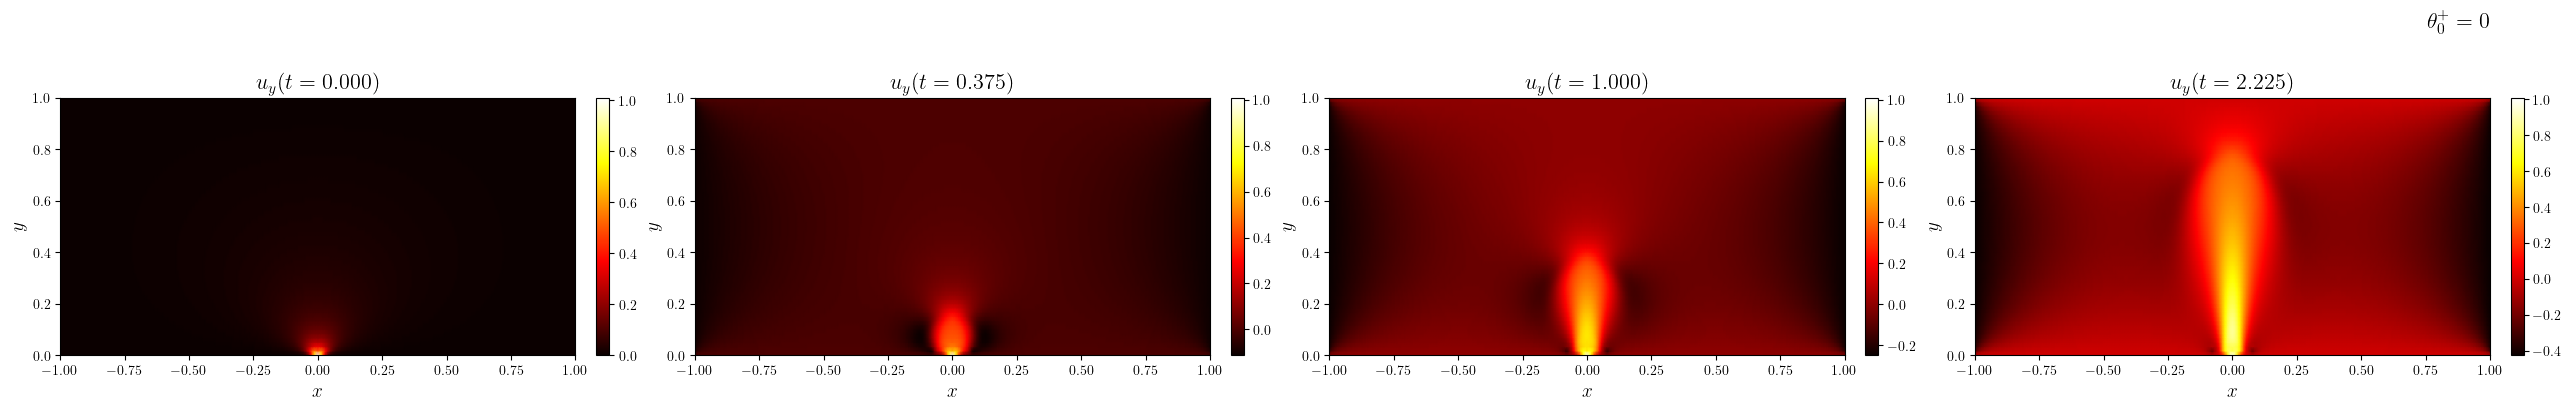

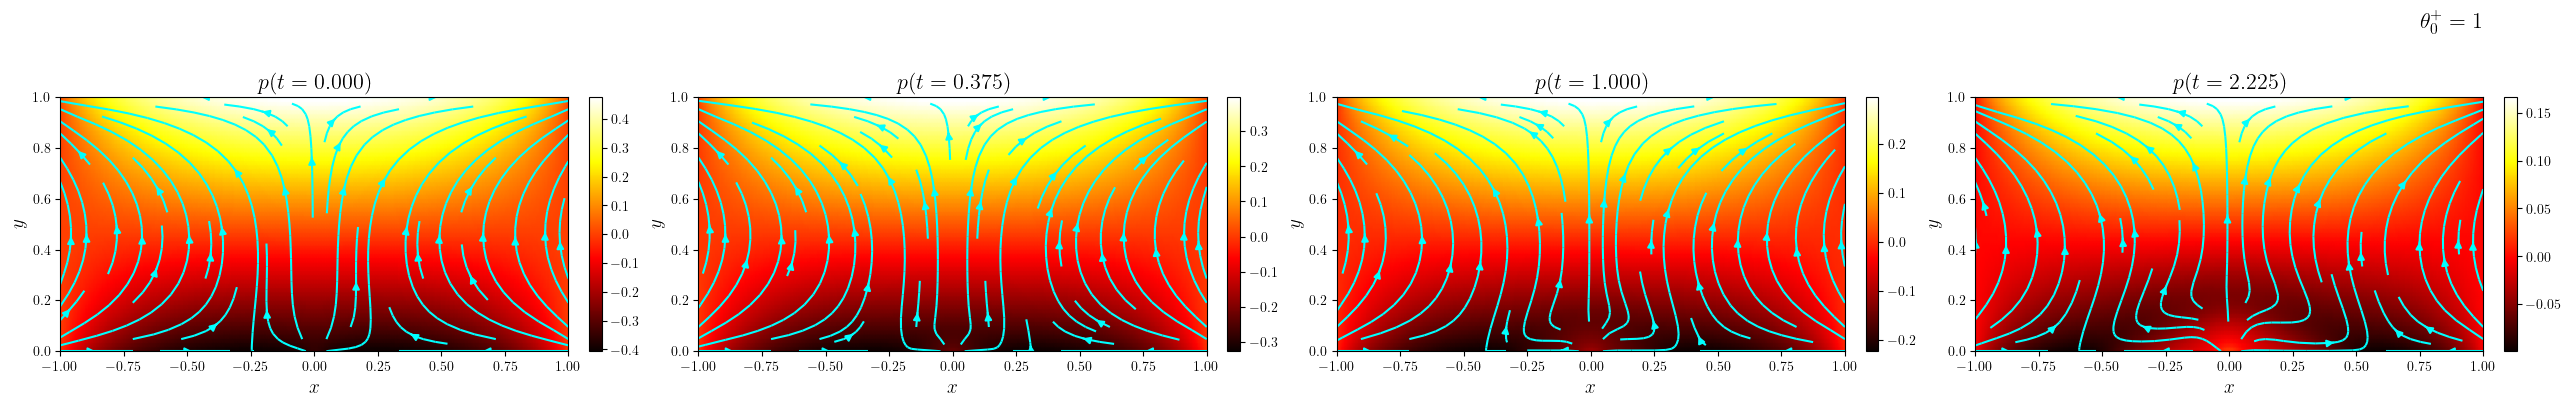

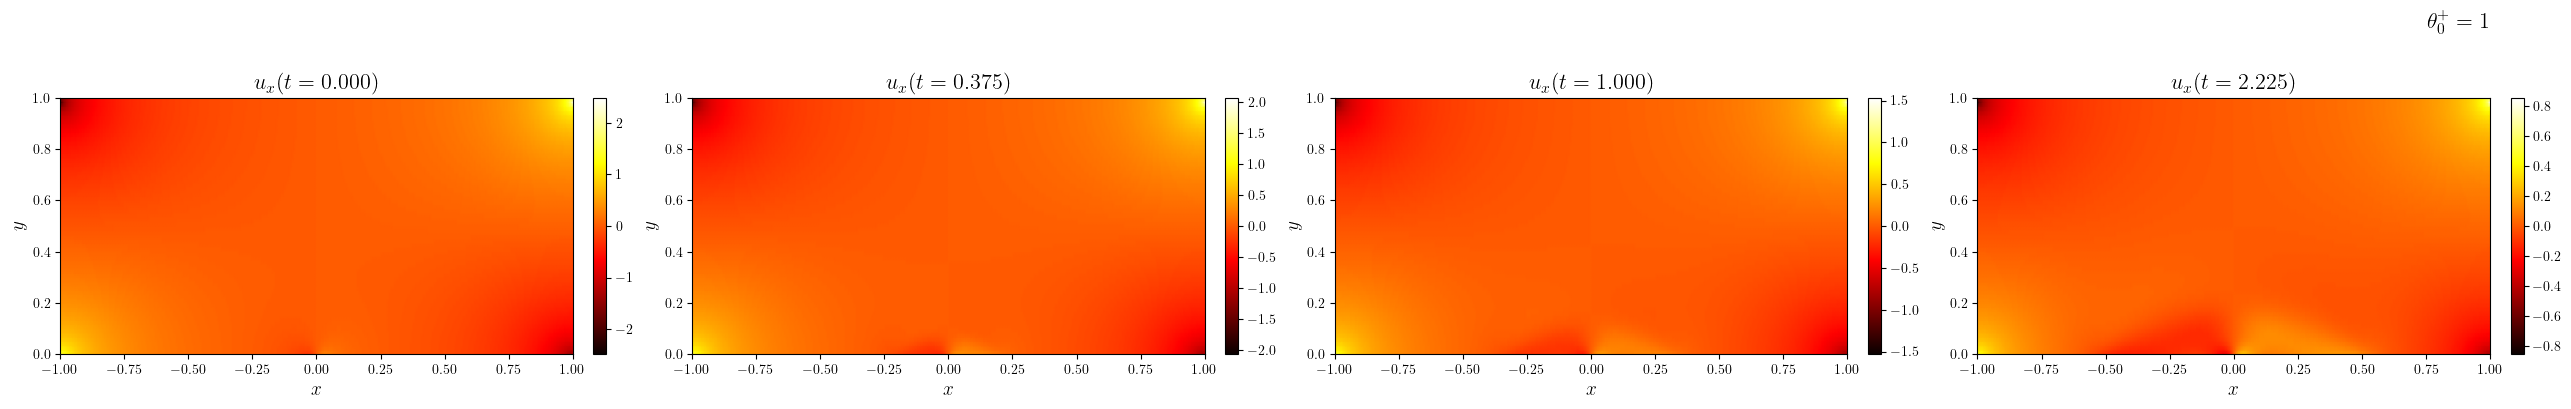

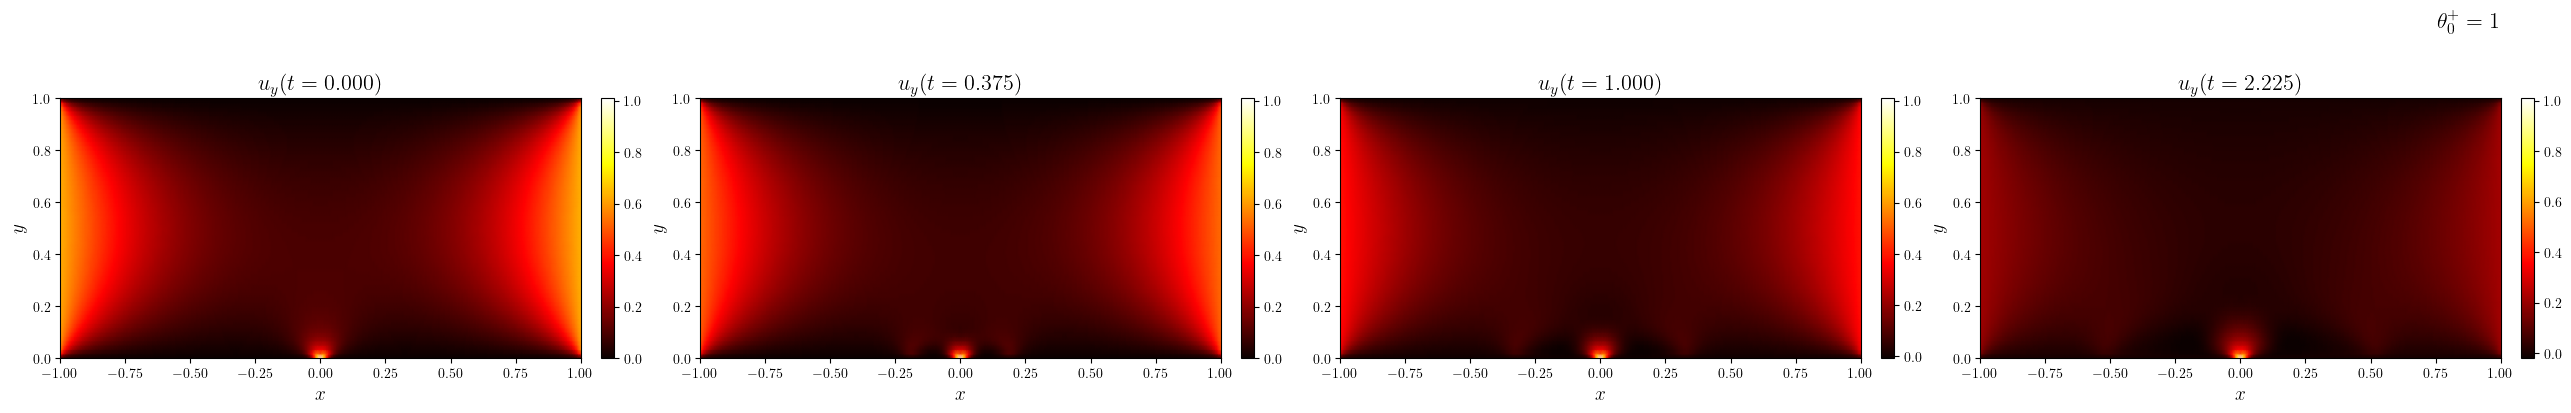

In [ ]:
time_indices = (*[int(i * n_stop) for i in (0, 0.25, 0.5)], -1)

for theta_buoy, sim in simulations.items():
    u, p = sim['u', 'p']
    mfig_p, axs_p, _ = plot_colormap_multifigure(
        n_cols=len(time_indices), 
        cbars=True,
        suptitle=theta_title(theta_buoy),
    )(
        [mirrored(p.get_series_item(i)) for i in time_indices],
        title=[f'$p(t={p.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'p(t)_streamlines_theta_buoy={theta_buoy}', sim.dir_path, prefix=False)(mfig_p)
    ux, uy = [], []
    for i, ax in zip(time_indices, axs_p):
        uxi, uyi = extract_component_functions(('P', 1), u.get_series_item(i))
        uxi, uyi = mirrored(uxi, -1), mirrored(uyi)
        plot_streamlines(mfig_p, ax, (uxi, uyi), density=0.75, color='cyan')
        ux.append(uxi)
        uy.append(uyi)
    mfig_ux, *_ = plot_colormap_multifigure(
        n_cols=len(time_indices), 
        cbars=True,
        suptitle=theta_title(theta_buoy),
    )(
        ux,
        title=[f'$u_x(t={u.time_series[i]:.3f})$' for i in time_indices],
    )
    mfig_uy, *_ = plot_colormap_multifigure(
        n_cols=len(time_indices), 
        cbars=True,
        suptitle=theta_title(theta_buoy),
    )(
        uy,
        title=[f'$u_y(t={u.time_series[i]:.3f})$' for i in time_indices],
    )

### Thumbnail image

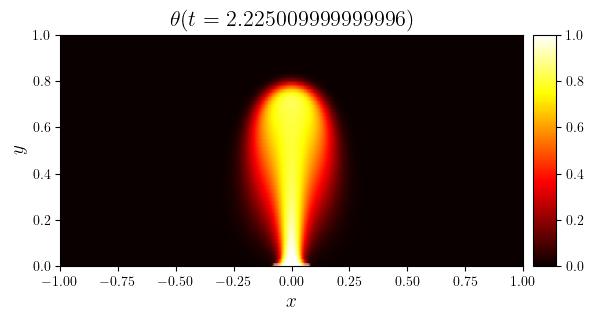

In [ ]:
time_index = -1
theta = simulations[True]['theta']
fig, ax = plot_colormap(
    mirrored(theta.series[time_index]), 
    title=f'$\\theta(t={theta.time_series[time_index]})$',
)
save_figure('thumbnail', DIR_ROOT, prefix=False)(fig, file_ext='png')